## Introduction

The goal of this project is to predict whether a customer will default on their credit payment next month.

This is a binary classification problem:
- 1 = Default
- 0 = No default

This problem is important because accurate predictions help financial institutions manage risk, while also raising fairness concerns in decision-making.

##Downloading the Dependencies
* Here are all the libraries and dependencies required for this project

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier

##Loading the Data
* I used Google Colab for this project and the dataset will be downloaded from UC Irvine's dataset pile. This dataset contains, "research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods."






In [17]:
#@ Loading the dataset
path = '/content/drive/MyDrive/Github repos/default of credit card clients.csv'
df = pd.read_csv(path, header = 1)

#@ Inspecting the data.
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

##Exploratory Data Analysis
## Understanding the Data

The dataset contains customer demographic information, credit history, and payment behavior.

### Key Variables

- **LIMIT_BAL**: Credit limit
- **SEX**: Gender (1 = Male, 2 = Female)
- **MARRIAGE**: Marital status
- **AGE**: Age

### Payment History

- **PAY_0 – PAY_6**: Repayment status (ordinal)
  - -1 = Paid duly
  - Higher values = more delay

### Financial Variables

- **BILL_AMT1–6**: Bill amounts
- **PAY_AMT1–6**: Payment amounts

### Target Variable

- **default payment next month**:
  - 1 = Default
  - 0 = No default

**Encoding Considerations**

- Some variables (e.g., SEX, MARRIAGE) are categorical but encoded numerically.
- Payment status variables are treated as ordinal features.
- We assume numeric encoding preserves meaningful order for repayment status.


In [19]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


##Data Cleaning
* Here, I tried to find the best corelation to see what matters the most to find the default payment next month. Instead of looking at all the correlation, we only focus on what's important.

## Feature Relationships

We analyze correlations between features and the target variable to identify important predictors.

The correlation matrix shows that **PAY_0 (recent repayment status)** has the strongest relationship with default.

This suggests that recent payment behavior is a key indicator of future default.

In [20]:
corr_target = df.corr()['default payment next month'].sort_values(ascending = False)
print(corr_target)

default payment next month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default payment nex

##Correlation Visualization
* I tried to show the heatmap and Barchart for easier evaluation.

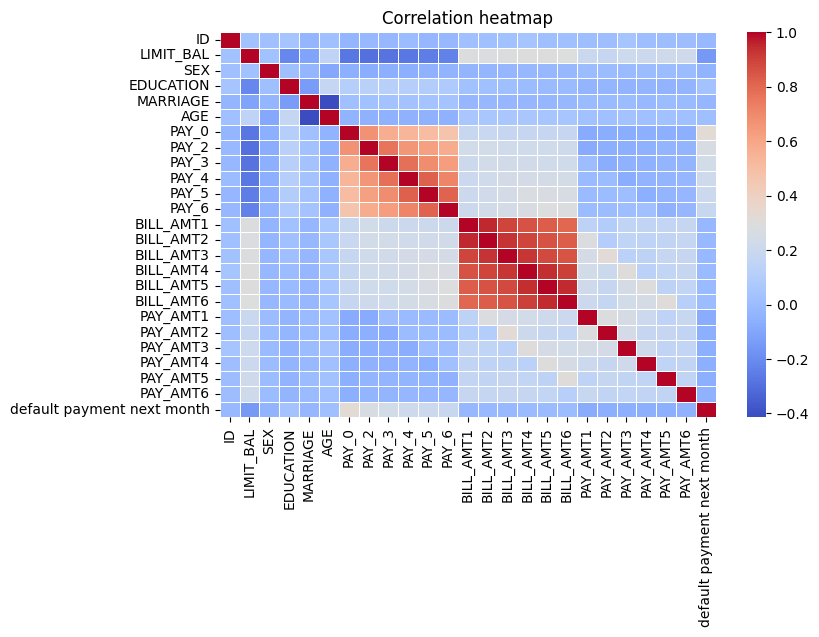

In [21]:
# Heatmap
corr_matrix = df.corr()
plt.figure(figsize = (8, 5))
sns.heatmap(corr_matrix, annot= False, cmap = 'coolwarm', linewidths = 0.5)
plt.title('Correlation heatmap')
plt.show()

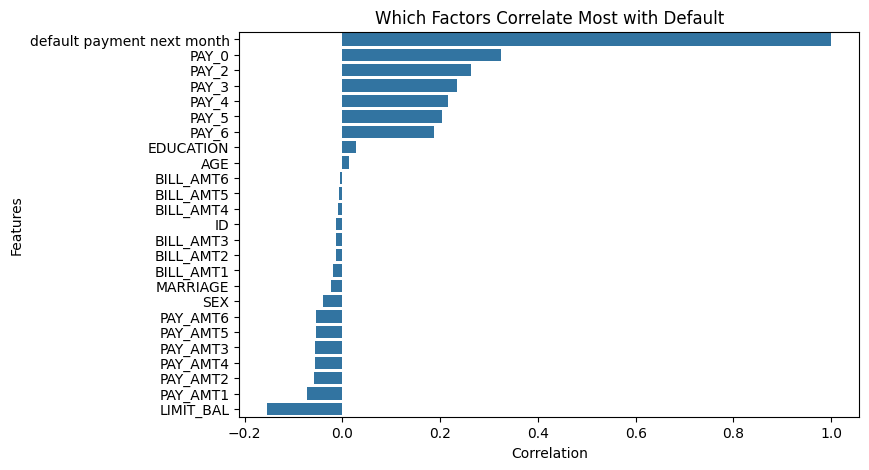

In [22]:
# Bar Chart
plt.figure(figsize = (8, 5))
sns.barplot(x = corr_target.values, y = corr_target.index)
plt.title('Which Factors Correlate Most with Default')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()

## Dataset-Level Fairness Analysis

We examine whether default rates differ across gender groups.

### Interpretation

The results show that default rates differ between males and females.

This reflects **underlying patterns in the dataset**, not necessarily bias introduced by the model.

However, this raises a concern:
- The model may learn these patterns and treat groups differently.

We will evaluate this further after building the model.

Group Representation Counts:
SEX_LABEL
Female    18112
Male      11888
Name: count, dtype: int64

Default Rates by Gender:
SEX_LABEL
Female    0.207763
Male      0.241672
Name: default payment next month, dtype: float64


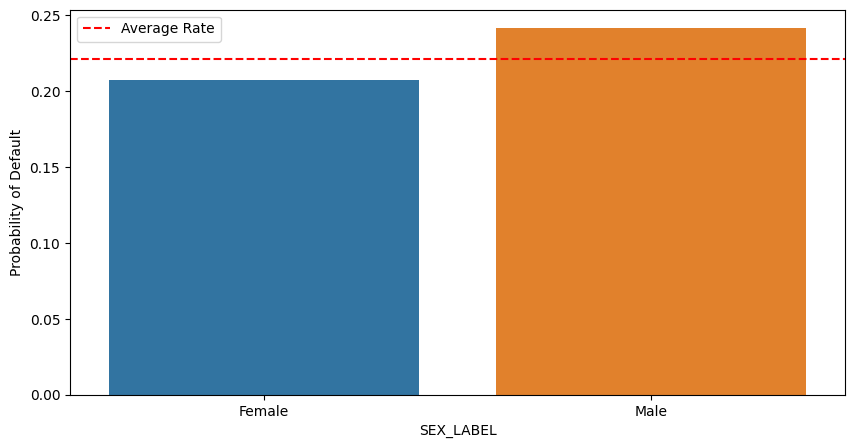

In [32]:
# Create a mapping for easier reading
df['SEX_LABEL'] = df['SEX'].map({1: 'Male', 2: 'Female'})
df['MARRIAGE_LABEL'] = df['MARRIAGE'].map({1: 'Married', 2: 'Single', 3: 'Others'})

# 1. Check representation (Are there more men or women?)
print("Group Representation Counts:")
print(df['SEX_LABEL'].value_counts())

# 2. Check the Default Rate by Group (This is where bias is found)
# 'default payment next month' is your target variable
fairness_check = df.groupby('SEX_LABEL')['default payment next month'].mean()

print("\nDefault Rates by Gender:")
print(fairness_check)

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=fairness_check.index, y=fairness_check.values, hue=fairness_check.index, legend=False)
plt.ylabel('Probability of Default')
plt.axhline(df['default payment next month'].mean(), color='red', linestyle='--', label='Average Rate')
plt.legend()
plt.show()

## Data Preprocessing

Before training models, we prepare the data:

- Split into training and test sets
- Scale numerical features (for Logistic Regression)
- Preserve categorical encodings

This ensures that models are trained and evaluated properly.

In [23]:
# Splitting data in X and y
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Splitting the 70% data for training and 20% data for testing.
X = df.drop('default payment next month', axis = 1)
y = df['default payment next month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 13)

In [35]:
# Scaling the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline Model

To evaluate whether our model is meaningful, we come up with a simple baseline model that always predicts the majority class.

A useful model should outperform this baseline.

In [39]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Baseline model: always predicts the most frequent class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_dummy_pred = dummy.predict(X_test)

baseline_acc = accuracy_score(y_test, y_dummy_pred)
print("Baseline Accuracy (Most Frequent Class):", baseline_acc)

Baseline Accuracy (Most Frequent Class): 0.779


## Modeling Approach

We use two models:

- **Logistic Regression** (interpretable baseline model)
- **Random Forest** (non-linear model)

We also apply:
- Feature scaling (for LR)
- Hyperparameter tuning (GridSearchCV)

These models allow us to compare performance and complexity.

In [40]:
# Logistic Regression
lr = LogisticRegression(max_iter = 1000, class_weight = 'balanced', solver = 'lbfgs', random_state = 13, C = 1.0)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
score = accuracy_score(y_test, lr_pred)
score


0.6921666666666667

In [37]:
print("Confusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report: ")
print(classification_report(y_test, lr_pred))


Confusion Matrix
[[3297 1377]
 [ 470  856]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.88      0.71      0.78      4674
           1       0.38      0.65      0.48      1326

    accuracy                           0.69      6000
   macro avg       0.63      0.68      0.63      6000
weighted avg       0.77      0.69      0.71      6000



In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestClassifier(class_weight = 'balanced', random_state = 42)
grid = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 5, scoring = 'roc_auc', n_jobs = -1)
grid.fit(X_train_scaled, y_train)

print("Best Parameters: ", grid.best_params_)
print("Best Score: ", grid.best_score_)

Best Parameters:  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Score:  0.7781954356892463


In [28]:
y_pred = grid.predict(X_test_scaled)
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report: ")
print(classification_report(y_test, y_pred))


Confusion Matrix
[[4260  414]
 [ 705  621]]

Classification Report: 
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      4674
           1       0.60      0.47      0.53      1326

    accuracy                           0.81      6000
   macro avg       0.73      0.69      0.70      6000
weighted avg       0.80      0.81      0.80      6000



## Results

We evaluate model performance using accuracy.

Both models outperform the baseline, indicating that they successfully learn patterns from the data.

However, performance alone is not sufficient, we must also assess fairness.

In [42]:
print("Baseline Accuracy:", baseline_acc)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.779
Logistic Regression Accuracy: 0.6921666666666667
Random Forest Accuracy: 0.8135


## Fairness Analysis

We analyze fairness at two levels:

### 1. Dataset-Level Differences
We observe that default rates differ across gender groups.  
This reflects underlying patterns in the data and may indicate pre-existing imbalance.

### 2. Model-Level Behavior
We evaluate model performance across gender using:
- Accuracy by group
- Predicted default rates

### Interpretation

- The accuracy plot shows whether the model performs equally well for different gender groups.
- The predicted default rate shows whether one group is more likely to be classified as high risk.

If there are noticeable differences between groups:
- This may indicate potential bias in the model.
- Differences may come from underlying data imbalance or model behavior.

This analysis highlights possible disparities but does not fully prove fairness or unfairness.

### Does the model perform differently across groups?

- If accuracy differs, the model performs better for one group.
- If predicted default rates differ, one group may be more likely to be classified as high risk.

This suggests potential disparities in model behavior.

### Trade-offs Between Accuracy and Fairness

- Features like PAY_0 improve accuracy but may reflect group-level differences.
- Optimizing for accuracy alone may unintentionally reinforce these differences.
- Addressing fairness may require sacrificing some predictive performance.

### Assumptions

- Encoded variables correctly represent real-world meaning
- Training and test data come from the same distribution

### Limitations

- The dataset may contain historical or societal bias
- Correlation does not imply causation
- The model may learn indirect relationships linked to sensitive attributes

In [64]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Add predictions to test set
X_test_copy = X_test.copy()
X_test_copy['y_true'] = y_test
X_test_copy['y_pred'] = y_pred

# Adding gender labels
X_test_copy['SEX'] = df.loc[X_test_copy.index, 'SEX']
X_test_copy['SEX_LABEL'] = X_test_copy['SEX'].map({1: 'Male', 2: 'Female'})

# Evaluate accuracy by gender
accuracy_data = []

for group in X_test_copy['SEX_LABEL'].unique():
    subset = X_test_copy[X_test_copy['SEX_LABEL'] == group]
    acc = accuracy_score(subset['y_true'], subset['y_pred'])
    accuracy_data.append({'SEX_LABEL': group, 'Accuracy': acc})

accuracy_df = pd.DataFrame(accuracy_data)

print(accuracy_df)

  SEX_LABEL  Accuracy
0      Male  0.803422
1    Female  0.820200


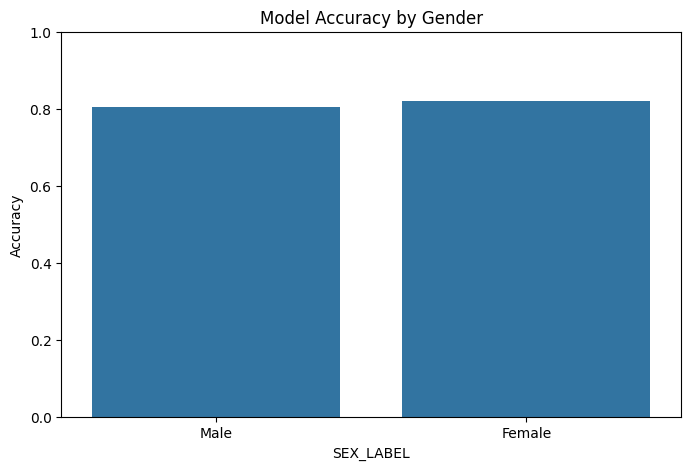

In [65]:
plt.figure(figsize=(8, 5))
sns.barplot(data=accuracy_df, x='SEX_LABEL', y='Accuracy')
plt.title("Model Accuracy by Gender")
plt.ylim(0, 1)
plt.show()

In [68]:
rate_data = []

for group in X_test_copy['SEX_LABEL'].unique():
    subset = X_test_copy[X_test_copy['SEX_LABEL'] == group]
    rate = subset['y_pred'].mean()
    rate_data.append({'SEX_LABEL': group, 'Predicted Default Rate': rate})

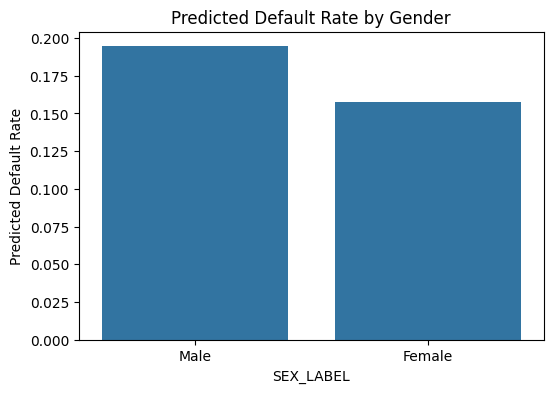

In [69]:
rate_df = pd.DataFrame(rate_data)

plt.figure(figsize=(6, 4))
sns.barplot(data=rate_df, x='SEX_LABEL', y='Predicted Default Rate')
plt.title("Predicted Default Rate by Gender")
plt.show()

### Conclusion and Final Decision

This analysis helps us identify potential disparities, but it does not fully establish fairness or unfairness.

### Should this model be used in practice?

The model shows strong predictive performance, but fairness concerns remain.

### If used:

- It should be applied with caution
- Additional fairness evaluation should be conducted
- Monitoring should be implemented to detect bias over time

### If not:

- The model should be improved before deployment

